In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature

import matplotlib.colors as colors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap

from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

In [3]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [4]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## Surface Temperature & net TOA radiation

In [5]:
# --- read data --- 

ds = xr.open_dataset('./Fig2_TS_TOA.nc')

ts_Mio_Ano = ds['TS_Ano']
toa_Mio_Ano = ds['TOA_Ano']

panel = np.empty((2, lat.size, lon.size))
panel = xr.DataArray(data=panel, dims=['var','lat','lon'], coords=[np.arange(1,2.5,1), lat, lon])
panel[0,:,:] = ts_Mio_Ano
panel[1,:,:] = toa_Mio_Ano

panel, lons = add_cyclic_point(panel, coord=lon)

''

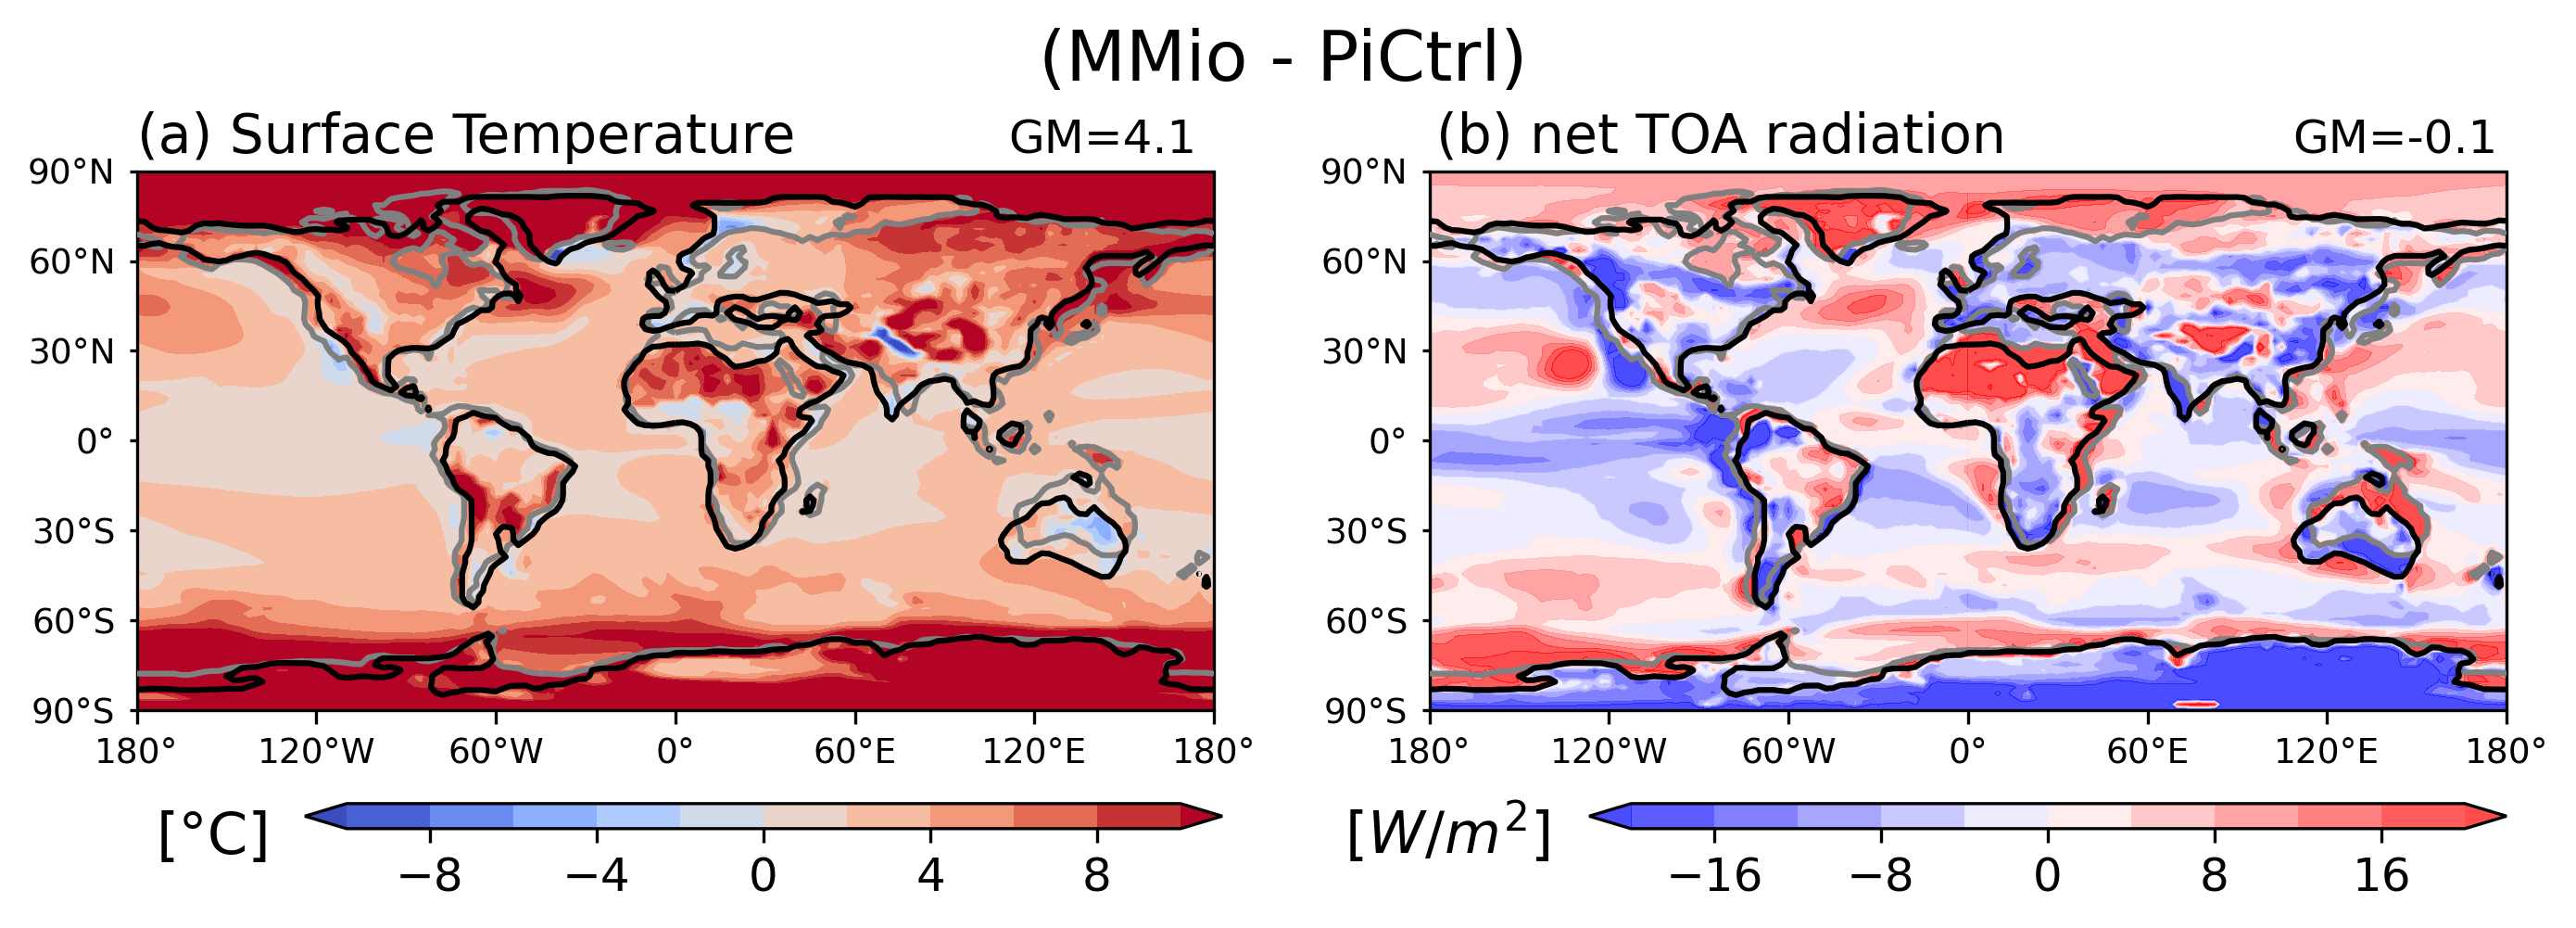

In [6]:
# Plot Anomalous pattern and also mark where its significant

var_species = ['Surface Temperature', 'net TOA radiation']

# --- plot ---

# Define the figure and each axis for the 4 rows and 3 columns
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(11,9), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.2, hspace=0.35) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(var_species):
        
    # Contour plot
    # Add coastines in Miocene Scenario
    if i==1:
        cs2=axs[i].contourf(lons,lat,panel[i,:,:], levels = np.linspace(-20, 20, 11),
                            transform = ccrs.PlateCarree(),
                            cmap='bwr', alpha=0.7, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='grey', linewidths=1.5, zorder=3)
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=4)        
    else:
        cs1=axs[i].contourf(lons,lat,panel[i,:,:], levels = np.linspace(-10, 10, 11),
                            transform = ccrs.PlateCarree(),
                            cmap='coolwarm', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='grey', linewidths=1.5, zorder=3)
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=4)        
    
    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        

ts_Mio_Ano_mean = ts_Mio_Ano.weighted(weights).mean(dim=['lon','lat']) 
toa_Mio_Ano_mean = toa_Mio_Ano.weighted(weights).mean(dim=['lon','lat']) 
GMST_Mio_Ano = 'GM='+str('{:03.1f}'.format(ts_Mio_Ano_mean.values))
GMTOA_Mio_Ano = 'GM='+str('{:03.1f}'.format(toa_Mio_Ano_mean.values))

# Add colorbar
cax1  = fig.add_axes([0.18, 0.34, 0.3, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB1   = plt.colorbar(cs1, cax = cax1, orientation='horizontal')
CB1.ax.tick_params(labelsize=12)

cax2  = fig.add_axes([0.6, 0.34, 0.3, 0.01])    # set the [x0, y0, width, height] of the colorbar
CB2   = plt.colorbar(cs2, cax = cax2, orientation='horizontal')
CB2.ax.tick_params(labelsize=12)

plt.figtext(0.15,0.33,'[°C]',ha='center',fontsize=15)
plt.figtext(0.52,0.33,'[$W/m^2$]',fontsize=15)

plt.figtext(0.125,0.61,'(a) Surface Temperature',fontsize=14)
plt.figtext(0.41,0.61,GMST_Mio_Ano,fontsize=12)
plt.figtext(0.55,0.61,'(b) net TOA radiation',fontsize=14)
plt.figtext(0.83,0.61,GMTOA_Mio_Ano,fontsize=12)

# Add title
plt.suptitle('(MMio - PiCtrl)', y=0.66, fontsize=18)
# fig.savefig('plot_TS.png')
;

## Total Dust Concentration & Total Dust Deposition

In [7]:
# --- read data --- 

ds_dust = xr.open_dataset('./Fig2_Dust.nc')

dst_Pi = ds_dust['dst_Pi']
dst_Mio = ds_dust['dst_Mio']
dst_dep_Pi = ds_dust['dst_dep_Pi']
dst_dep_Mio = ds_dust['dst_dep_Mio']

dst_Mio_ano = dst_Mio - dst_Pi
dst_dep_Mio_ano = dst_dep_Mio - dst_dep_Pi

dst_Pi = xr.DataArray(data=dst_Pi, dims=['lat','lon'], coords=[lat, lon])
dst_Mio_ano = xr.DataArray(data=dst_Mio_ano, dims=['lat','lon'], coords=[lat, lon])
dst_dep_Pi = xr.DataArray(data=dst_dep_Pi, dims=['lat','lon'], coords=[lat, lon])
dst_dep_Mio_ano = xr.DataArray(data=dst_dep_Mio_ano, dims=['lat','lon'], coords=[lat, lon])

panel_dust = np.empty((2, lat.size, lon.size))
panel_dust = xr.DataArray(data=panel_dust, dims=['var','lat','lon'], coords=[np.arange(1,2.5,1), lat, lon])
panel_dust[0,:,:] = dst_Mio_ano/10                    # (kg/m2) --> (g/cm2)
panel_dust[1,:,:] = dst_dep_Mio_ano*86400*365*100     # (kg/m2/s) --> (g/cm2/kyr)

panel_dust, lons = add_cyclic_point(panel_dust, coord=lon)

In [8]:
dst_Pi_mean = dst_Pi.weighted(weights).mean(dim=['lon','lat']) 
dst_Mio_ano_mean = dst_Mio_ano.weighted(weights).mean(dim=['lon','lat']) 
dst_ratio_Mio_ano_mean = 100*(dst_Mio_ano_mean / dst_Pi_mean)
dst_ratio_Mio_ano_mean

print(dst_Pi_mean.values)
print(dst_ratio_Mio_ano_mean.values)

dst_dep_Pi_mean = dst_dep_Pi.weighted(weights).mean(dim=['lon','lat']) 
dst_dep_Mio_ano_mean = dst_dep_Mio_ano.weighted(weights).mean(dim=['lon','lat']) 
dst_dep_ratio_Mio_ano_mean = 100*(dst_dep_Mio_ano_mean / dst_dep_Pi_mean)
dst_dep_ratio_Mio_ano_mean

print(dst_dep_Pi_mean.values)
print(dst_dep_ratio_Mio_ano_mean.values)

2.2004074832682654e-05
-81.44347960873891
2.2168116384065126e-10
-72.03876429259068


/glade/derecho/scratch/pjchen/tmp/ipykernel_63203/2440367977.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  neg_colors = plt.cm.get_cmap('PuOr_r')(np.linspace(0, 0.5, 32))
/glade/derecho/scratch/pjchen/tmp/ipykernel_63203/2440367977.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  pos_colors = plt.cm.get_cmap('PuOr_r')(np.linspace(0.5, 1, 32))


Text(0.75, 0.68, 'GM=-0.50  [-72.04%]')

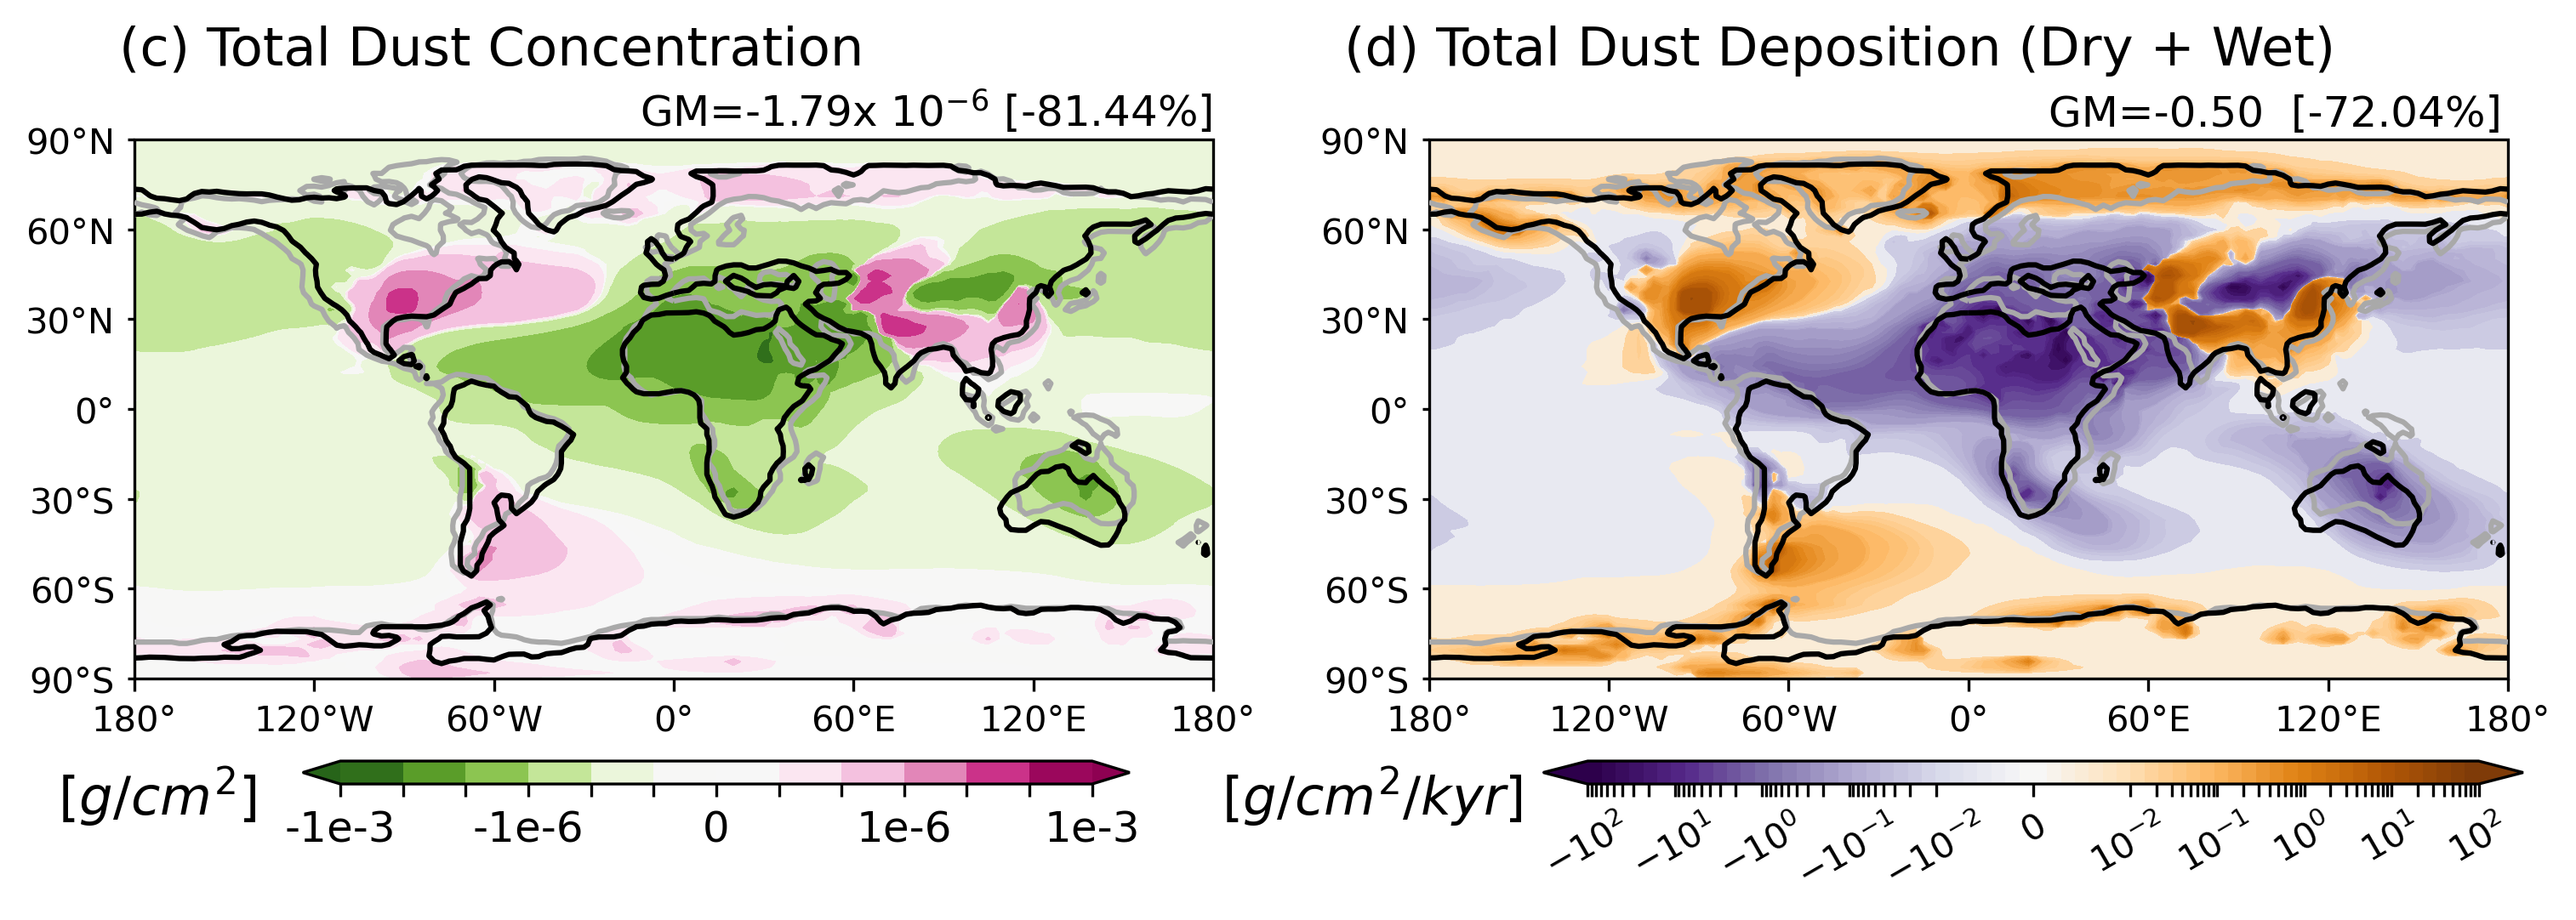

In [9]:
# Function of Plotting

# data_title = 'Total Dust [$kg/m^2$]'
dust_panel = ['Dust Concentrations', 'Dust Deposition']
plot_name = 'plot_Simulations_Dust_Anomaly'

bounds = [-100, -90, -80, -70, -60, -50, -40, -30, -20, -10, 
          -9, -8, -7, -6, -5, -4, -3, -2, -1, 
          -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 
          -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 
          0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
          0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
          1, 2, 3, 4, 5, 6, 7, 8, 9,
          10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
neg_colors = plt.cm.get_cmap('PuOr_r')(np.linspace(0, 0.5, 32)) 
pos_colors = plt.cm.get_cmap('PuOr_r')(np.linspace(0.5, 1, 32)) 
colors_list = np.vstack((neg_colors, pos_colors))

cmap_d = mcolors.ListedColormap(colors_list)
norm_d = mcolors.SymLogNorm(linthresh=0.01, vmin=-100, vmax=100, base=10)
mappable = plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d)


levels2 = [-1e-3, -1e-4, -1e-5, -1e-6, -1e-7, -1e-8, 0,
           1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
levels_label2 = ['-1e-3', '', '', '-1e-6', '', '', '0',
                 '', '', '1e-6', '', '', '1e-3']
norm2 = mcolors.SymLogNorm(linthresh=1e-8, linscale=1e-3, vmin=-1e-3, vmax=1e-3)
locator = mticker.SymmetricalLogLocator(linthresh=0.0001, base=10)


    
# Define the figure and each axis for the 1 rows and 2 columns
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)},
                        figsize=(12,6), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.2, hspace=0.2) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(dust_panel):
        
    # Contour plot
    if i==1:
        cs4=axs[i].contourf(lons, lat, panel_dust[i,:,:], transform = ccrs.PlateCarree(), 
                            levels = bounds, norm = norm_d, cmap=cmap_d, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5], transform = ccrs.PlateCarree(),
                       colors='darkgrey', linewidths=1.5, zorder=3)
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5], transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=4)   
    else:
        cs3=axs[i].contourf(lons, lat, panel_dust[i,:,:], transform = ccrs.PlateCarree(),
                           levels = levels2, norm = norm2, cmap='PiYG_r',extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5], transform = ccrs.PlateCarree(),
                       colors='darkgrey', linewidths=1.5, zorder=3)
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5], transform = ccrs.PlateCarree(),
                       colors='k', linewidths=1.5, zorder=4)        

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(10)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(10)               
        
# Add colorbar
cax4  = fig.add_axes([0.585, 0.25, 0.32, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB4   = plt.colorbar(mappable, cax=cax4, shrink=0.8, location='bottom', ticks=bounds, extend='both', 
                     spacing='proportional', pad=0.05)
CB4.ax.tick_params(rotation=30, labelsize=10)


cax3  = fig.add_axes([0.18, 0.25, 0.27, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB3   = plt.colorbar(cs3, cax = cax3, orientation='horizontal')
CB3.set_ticks(levels2)
CB3.set_ticklabels(levels_label2)
CB3.ax.tick_params(labelsize=12)


GM_Mio_Ano = 'GM='+str('{:03.2f}'.format(dst_Mio_ano_mean.values*1e6/10))+'x $10^{-6}$ ['+str('{:03.2f}'.format(dst_ratio_Mio_ano_mean.values))+'%]'
GM_dep_Mio_Ano = 'GM='+str('{:03.2f}'.format(dst_dep_Mio_ano_mean.values*86400*365*100))+'  ['+str('{:03.2f}'.format(dst_dep_ratio_Mio_ano_mean.values))+'%]'

# plt.figtext(0.1,0.23,'[$kg/m^2$]',fontsize=15)
# plt.figtext(0.5,0.23,'[$kg/m^2/s$]',fontsize=15)
plt.figtext(0.1,0.23,'[$g/cm^2$]',fontsize=15)
plt.figtext(0.48,0.23,'[$g/cm^2/kyr$]',fontsize=15)

plt.figtext(0.12,0.72,'(c) Total Dust Concentration',fontsize=15)
plt.figtext(0.29,0.68,GM_Mio_Ano,fontsize=12)
plt.figtext(0.52,0.72,'(d) Total Dust Deposition (Dry + Wet)',fontsize=15)
plt.figtext(0.75,0.68,GM_dep_Mio_Ano,fontsize=12)


# Add title
# plt.suptitle(data_title, y=0.7, fontsize=18)
# fig.savefig(plot_name+'.png')

## Ice Fraction

In [10]:
# --- read data --- 

ds_ice = xr.open_dataset('./Fig2_ICEFRAC.nc')

ice_Pi = ds_ice['ICEFRAC_Pi']
ice_Mio = ds_ice['ICEFRAC_Mio']
ice_Mio_ano = ice_Mio - ice_Pi
ice_Mio_ano = xr.DataArray(data=ice_Mio_ano, dims=['lat','lon'], coords=[lat, lon])

panel_ice = np.empty((2, lat.size, lon.size))
panel_ice = xr.DataArray(data=panel_ice, dims=['var','lat','lon'], coords=[np.arange(1,2.5,1), lat, lon])
panel_ice[0,:,:] = ice_Mio_ano*100             
panel_ice[1,:,:] = ice_Mio_ano*100

ice_title = ['(e) North Pole','(f) South Pole']
panel_ice, lons = add_cyclic_point(panel_ice, coord=lon)
panel_ice[(panel_ice > -0.05) & (panel_ice < 0.05)] = np.nan  # simulate ocean as NaN

/glade/derecho/scratch/pjchen/tmp/ipykernel_63203/777437736.py:47: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axs[i] = plt.subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
/glade/work/pjchen/conda-envs/Mio/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/glade/work/pjchen/conda-envs/Mio/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)


''

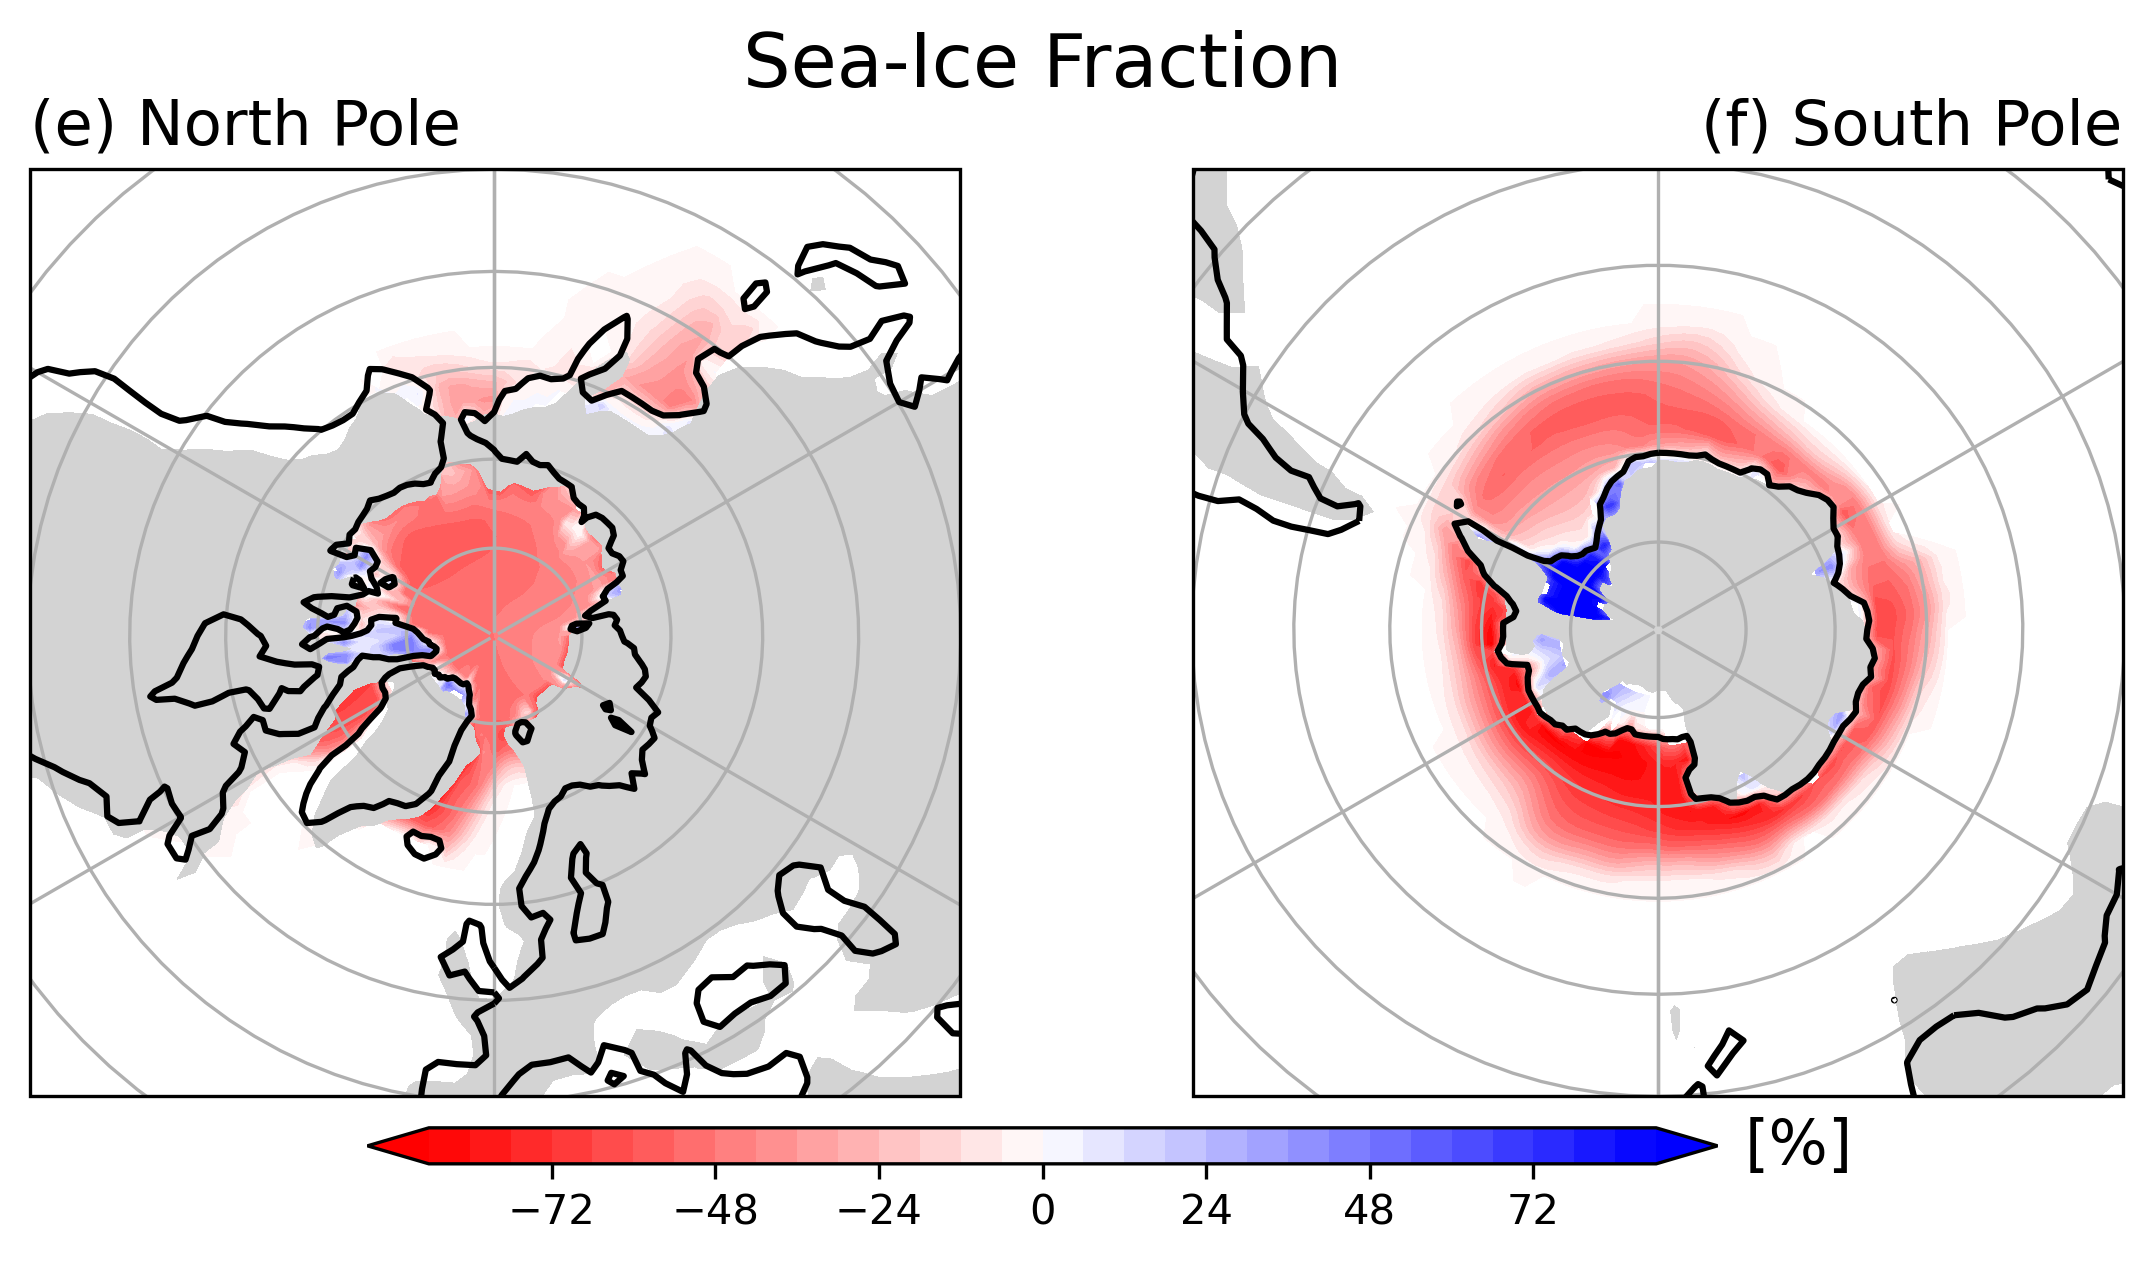

In [11]:
# --- plot ---

norm = TwoSlopeNorm(vmin=-90, vcenter=0, vmax=90)

rwb = LinearSegmentedColormap.from_list(
    'custom_rwb',
    ['red', 'white', 'blue'],  # order matters!
    N=256  # number of color levels
)
rwb.set_bad(color='white')

# Define the figure and each axis for the 1 rows and 2 columns
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.SouthPolarStereo(central_longitude=0)},
                        figsize=(9,6), dpi=300)

# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.25, hspace=0.35) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(ice_title):
        
    # Contour plot
    if i==1:
        cs2=axs[i].contourf(lons,lat,panel_ice[i,:,:], levels = np.linspace(-90, 90, 31),
                            transform = ccrs.PlateCarree(), 
                            # norm=norm, cmap='seismic_r',
                            cmap=rwb, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='black', linewidths=1.5, zorder=3)
        axs[i].contourf(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='lightgrey', linewidths=1.5)
        axs[i].set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())  
        
        # Add gridlines
        axs[i].gridlines(crs=ccrs.PlateCarree(), y_inline=True, ylocs=range(-90,0,10),
                         colors='white', zorder=2)
        axs[i].set_title(ice_title[i], loc='right', fontsize=15)    
        
    else:
        axs[i] = plt.subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())
        cs2=axs[i].contourf(lons,lat,panel_ice[i,:,:], levels = np.linspace(-90, 90, 31),
                            transform = ccrs.PlateCarree(), 
                            # norm=norm, shading='auto', cmap='seismic_r',
                            cmap=rwb, extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(),
                       colors='black', linewidths=1.5, zorder=3)
        # Add coastines in Miocene Scenario
        axs[i].contourf(lons, lat, mask_Mio, [0.5,1.5],
                        transform = ccrs.PlateCarree(),
                        colors='lightgrey', linewidths=1.5)
        axs[i].set_extent([-180, 180, 40, 90], crs=ccrs.PlateCarree())  
        
        # Add gridlines
        axs[i].gridlines(crs=ccrs.PlateCarree(), y_inline=True, ylocs=range(0,90,10),
                         colors='white', zorder=2)
        
        # Title each subplot with the name of the month
        axs[i].set_title(ice_title[i], loc='left', fontsize=15)      
 
        
# Add colorbar
cax2 = fig.add_axes([0.25, 0.2, 0.5, 0.02])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')


# Add colobar's title
plt.figtext(0.78,0.2,'[%]',ha='center',fontsize=15)
# Add title
plt.suptitle('Sea-Ice Fraction', y=0.83, fontsize=18)
# fig.savefig('plot_TS.png')
;